<a href="https://colab.research.google.com/github/sujitx-vs/PGCP-AI_PML/blob/main/Day7_PML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [ ]:
df = pd.read_csv('/content/Day5.csv')

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
df.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df = df.drop('User ID',axis = 1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Gender']= encoder.fit_transform(df['Gender'])

In [ ]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


In [ ]:
X = df.iloc[:,:-1]

In [ ]:
Y = df.iloc[:,-1]

In [ ]:

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=.2,random_state=0)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

<Axes: xlabel='Age', ylabel='Count'>

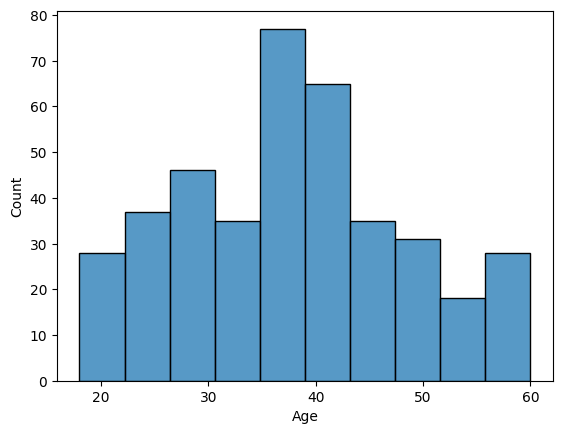

In [ ]:
sns.histplot(df['Age'])

<Axes: xlabel='Gender', ylabel='EstimatedSalary'>

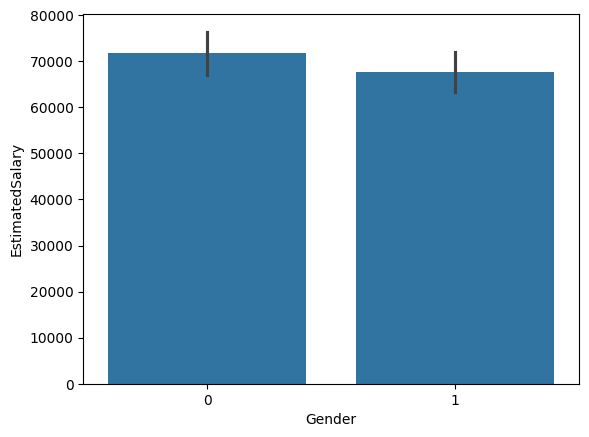

In [ ]:
sns.barplot( y='EstimatedSalary', x= 'Gender', data= df)

<Axes: >

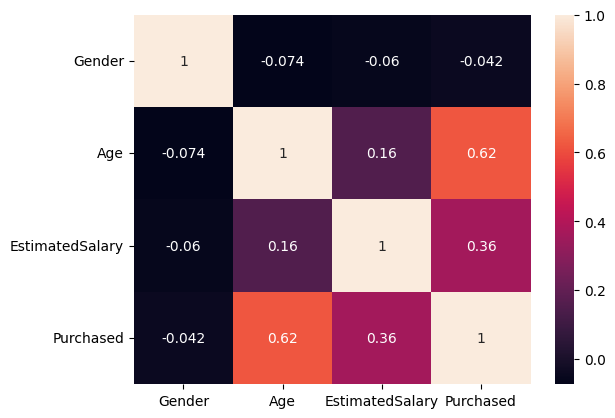

In [ ]:
sns.heatmap(df.corr(),annot= True)

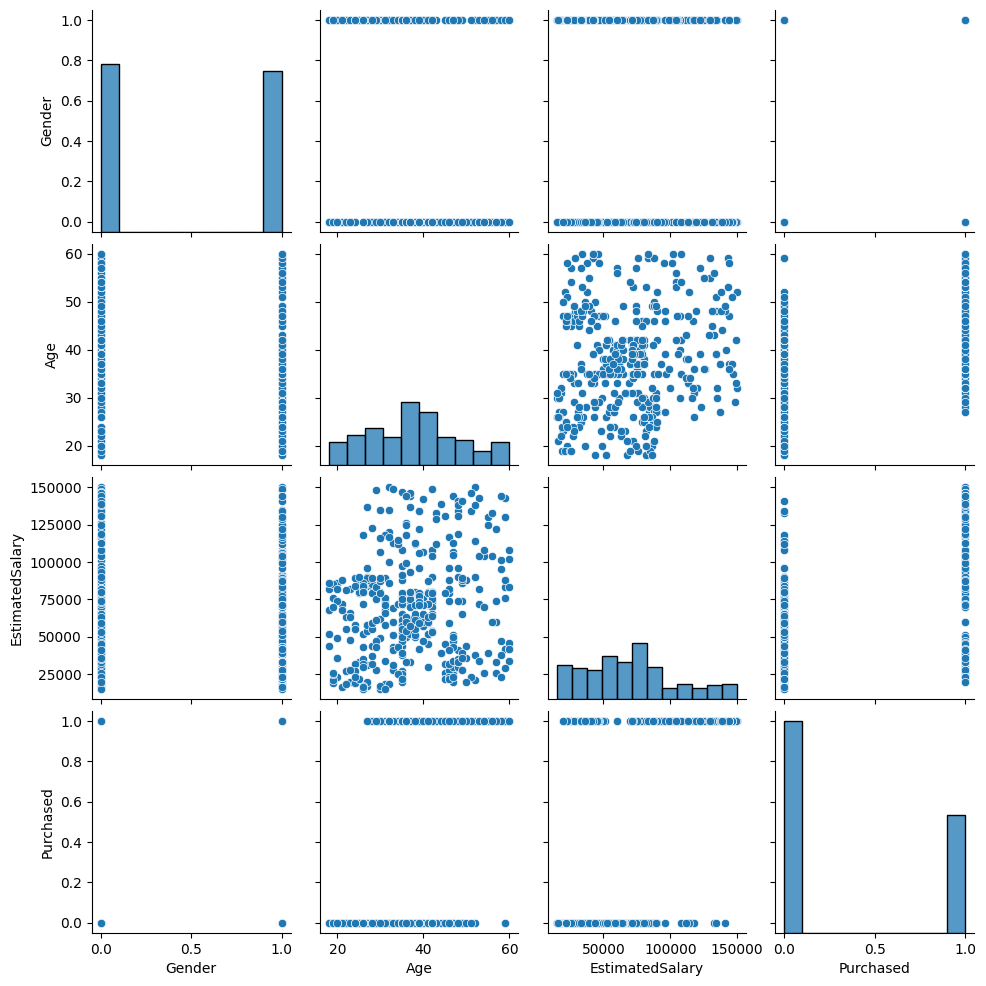

In [ ]:
sns.pairplot(df)

In [ ]:
lg = LogisticRegression()

lg.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lg.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error,confusion_matrix,accuracy_score,classification_report

In [ ]:
mean_squared_error(y_test,y_pred)

0.1125

In [ ]:
r2_score(y_test,y_pred)

0.4357366771159875

In [ ]:
confusion_matrix(y_test,y_pred)

array([[52,  6],
       [ 3, 19]])

In [ ]:
accuracy_score(y_test,y_pred)

0.8875

In [ ]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.95      0.90      0.92        58\n           1       0.76      0.86      0.81        22\n\n    accuracy                           0.89        80\n   macro avg       0.85      0.88      0.86        80\nweighted avg       0.89      0.89      0.89        80\n'

Navie Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
modelNB = GaussianNB()

In [ ]:
modelNB.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_predNB = modelNB.predict(x_test)

In [ ]:
accuracy_score(y_test,y_predNB)

0.9375

In [ ]:
confusion_matrix(y_test,y_predNB)

array([[54,  4],
       [ 1, 21]])

In [ ]:
classification_report(y_test,y_predNB)

'              precision    recall  f1-score   support\n\n           0       0.98      0.93      0.96        58\n           1       0.84      0.95      0.89        22\n\n    accuracy                           0.94        80\n   macro avg       0.91      0.94      0.92        80\nweighted avg       0.94      0.94      0.94        80\n'

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_predKnn = knn.predict(x_test)

In [ ]:
classification_report(y_test,y_predKnn)

'              precision    recall  f1-score   support\n\n           0       0.98      0.91      0.95        58\n           1       0.81      0.95      0.88        22\n\n    accuracy                           0.93        80\n   macro avg       0.89      0.93      0.91        80\nweighted avg       0.93      0.93      0.93        80\n'

In [ ]:
confusion_matrix(y_test,y_predKnn)

array([[53,  5],
       [ 1, 21]])

In [ ]:
accuracy_score(y_test,y_predKnn)

0.925

new Data

In [ ]:
#First feature
weather=['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny',
'Rainy','Sunny','Overcast','Overcast','Rainy']
#Second Feature
temp=['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild']

#Label
play=['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']


data={
    "weather":weather,
    "temp":temp,
    "play":play
}

In [ ]:
wdata = pd.DataFrame(data)

In [ ]:
wdata

,weather,temp,play
0,Sunny,Hot,No
1,Sunny,Hot,No
2,Overcast,Hot,Yes
3,Rainy,Mild,Yes
4,Rainy,Cool,Yes
5,Rainy,Cool,No
6,Overcast,Cool,Yes
7,Sunny,Mild,No
8,Sunny,Cool,Yes
9,Rainy,Mild,Yes


In [ ]:
wdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   weather  14 non-null     object
 1   temp     14 non-null     object
 2   play     14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


In [ ]:
wdata.describe()

,weather,temp,play
count,14,14,14
unique,3,3,2
top,Sunny,Mild,Yes
freq,5,6,9


In [ ]:
wdata.isna().sum()

,0
weather,0
temp,0
play,0


In [ ]:
wdata.duplicated().sum()

np.int64(3)

In [ ]:
wdata=wdata.drop_duplicates()

In [ ]:
wdata.duplicated().sum()

np.int64(0)

In [ ]:
encoder= LabelEncoder()

In [ ]:
wdata['weather'] = encoder.fit_transform(wdata['weather'])

/tmp/ipykernel_11947/1357378448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wdata['weather'] = encoder.fit_transform(wdata['weather'])


In [ ]:
wdata = pd.get_dummies(wdata, columns=['temp'], drop_first=False, dtype=int)
wdata

,weather,play,temp_Cool,temp_Hot,temp_Mild
0,2,No,0,1,0
2,0,Yes,0,1,0
3,1,Yes,0,0,1
4,1,Yes,1,0,0
5,1,No,1,0,0
6,0,Yes,1,0,0
7,2,No,0,0,1
8,2,Yes,1,0,0
10,2,Yes,0,0,1
11,0,Yes,0,0,1


In [ ]:
wdata['play'] = encoder.fit_transform(wdata['play'])

In [ ]:
wdata

,weather,play,temp_Cool,temp_Hot,temp_Mild
0,2,0,0,1,0
2,0,1,0,1,0
3,1,1,0,0,1
4,1,1,1,0,0
5,1,0,1,0,0
6,0,1,1,0,0
7,2,0,0,0,1
8,2,1,1,0,0
10,2,1,0,0,1
11,0,1,0,0,1


In [ ]:
X = wdata.drop('play',axis=1)

In [ ]:
Y = wdata['play']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
accuracy_score(y_test,y_pred)

0.6666666666666666

In [ ]:
confusion_matrix(y_test,y_pred)

array([[0, 1],
       [0, 2]])